# 4.6 Conditional Sensitivity to Initial Yield Curve

Evaluates how sensitive each model is to the initial yield curve by comparing
the **slope factor β₂** distributions across three interest rate regimes,
using only the **first 12 months** of each simulated scenario.


## Setup & Data Loading

import pandas as pd

# Load CSV
df = pd.read_csv("VAE.csv")

# Remove 2nd and 3rd columns
df = df.drop(df.columns[[1, 2]], axis=1)

# Save new CSV
df.to_csv("VAE_3 scenarios 10-5.csv", index=False)

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
from scipy.stats import wasserstein_distance
import warnings
warnings.filterwarnings("ignore")

# ── Maturity labels ─────────────────────────────────────────────────────────
MATURITIES = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
MAT_YEARS  = np.array([1/12,3/12,6/12,1,2,3,5,7,10,20,30])

# ── Nelson–Siegel (fixed λ) ─────────────────────────────────────────────────
LAMBDA = 0.0609
def ns_basis(t, lam=LAMBDA):
    lt = lam * t
    return np.column_stack([np.ones_like(t),
                            (1-np.exp(-lt))/lt,
                            (1-np.exp(-lt))/lt - np.exp(-lt)])
NS_BASIS = ns_basis(MAT_YEARS)   # (11, 3)

# ── Regime labels & colours ─────────────────────────────────────────────────
REGIMES = {
    1: "High-rate (2002–2004)",
    2: "Medium-rate (2012–2014)",
    3: "Low-rate (2018–2021)",
}
REGIME_COLORS = {1: "#C62828", 2: "#E6AC00", 3: "#1565C0"}

# ── Model colours ───────────────────────────────────────────────────────────
MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#8E24AA",
    "VAE":       "#EF6C00",
}

N_MONTHS = 12   # only first year


In [63]:
# ── Data loader ────────────────────────────────────────────────────────────
def _detect_mat_cols(df):
    bare     = [m for m in MATURITIES if m in df.columns]
    prefixed = [f"Y_{m}" for m in MATURITIES if f"Y_{m}" in df.columns]
    if len(bare)     == 11: return bare
    if len(prefixed) == 11: return prefixed
    raise ValueError(f"Cannot find maturity columns in {list(df.columns)}")

def load_conditional_data(path, n_scen=200):
    """Returns {regime_id: list of (T, 11) arrays}"""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    mat_cols = _detect_mat_cols(df)
    result = {}
    if "Start_Curve_ID" in df.columns:
        for rid in sorted(df["Start_Curve_ID"].unique()):
            sub  = df[df["Start_Curve_ID"] == rid]
            wins = [sub[sub["Scenario_ID"]==sid][mat_cols].values.astype(float)
                    for sid in sub["Scenario_ID"].unique()[:n_scen]]
            result[int(rid)] = [w for w in wins if w.shape[0] >= N_MONTHS]
    else:
        wins = [df[df["Scenario_ID"]==sid][mat_cols].values.astype(float)
                for sid in df["Scenario_ID"].unique()[:n_scen]]
        result[1] = [w for w in wins if w.shape[0] >= N_MONTHS]
    return result

# ── Fit β₂ for first N_MONTHS of each scenario ─────────────────────────────
def extract_beta2(windows, n_months=N_MONTHS):
    """
    windows : list of (T, 11) arrays
    returns : flat array of β₂ values  (N_scen × n_months)
    """
    betas = []
    for w in windows:
        for t in range(n_months):
            b, *_ = lstsq(NS_BASIS, w[t], rcond=None)
            betas.append(b[1])
    return np.array(betas)

# ── Load models ─────────────────────────────────────────────────────────────
MODELS = {
    "Diffusion": "diffusion_3 scenarios 6-5.csv",
    "HJM-PCA":   "hjm_pca_3 scenarios 6-5.csv",
    "CANN":    "cann_3 scenarios 10-5.csv",
    "VAE":     "VAE_3 scenarios 10-5.csv",
}

model_beta2 = {}   # model → {regime_id → β₂ array}
for name, path in MODELS.items():
    data = load_conditional_data(path)
    model_beta2[name] = {}
    for rid, windows in data.items():
        b2 = extract_beta2(windows)
        model_beta2[name][rid] = b2
        label = REGIMES.get(rid, f"Curve {rid}")
        print(f"  {name:12s} | {label:28s}: {len(windows):3d} scenarios, "
              f"{len(b2):5d} β₂ values  (mean = {b2.mean():.4f})")


  Diffusion    | High-rate (2002–2004)       : 200 scenarios,  2400 β₂ values  (mean = 5.2019)
  Diffusion    | Medium-rate (2012–2014)     : 200 scenarios,  2400 β₂ values  (mean = 2.9035)
  Diffusion    | Low-rate (2018–2021)        : 200 scenarios,  2400 β₂ values  (mean = 1.2583)
  HJM-PCA      | High-rate (2002–2004)       : 200 scenarios,  2400 β₂ values  (mean = 5.1445)
  HJM-PCA      | Medium-rate (2012–2014)     : 200 scenarios,  2400 β₂ values  (mean = 2.6024)
  HJM-PCA      | Low-rate (2018–2021)        : 200 scenarios,  2400 β₂ values  (mean = 0.7837)
  CANN         | High-rate (2002–2004)       : 200 scenarios,  2400 β₂ values  (mean = 5.0993)
  CANN         | Medium-rate (2012–2014)     : 200 scenarios,  2400 β₂ values  (mean = 2.2334)
  CANN         | Low-rate (2018–2021)        : 200 scenarios,  2400 β₂ values  (mean = 1.5165)
  VAE          | High-rate (2002–2004)       : 200 scenarios,  2400 β₂ values  (mean = 2.7197)
  VAE          | Medium-rate (2012–2014)     : 200

## β₂ Distribution per Regime

For each model: all three regime distributions on one plot (200 scenarios × 12 months = 2 400 values each).
Vertical dashed lines mark the mean of each distribution.


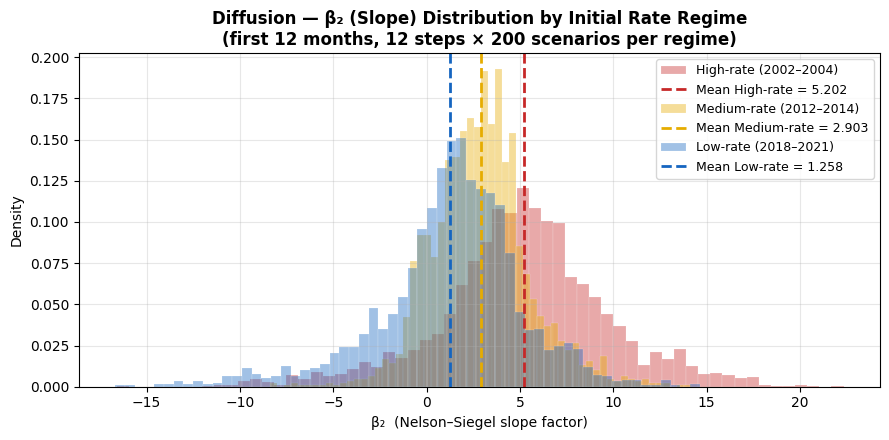

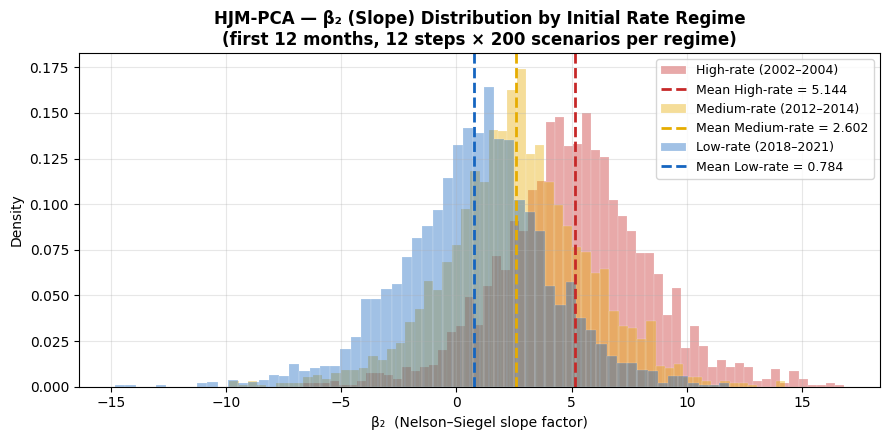

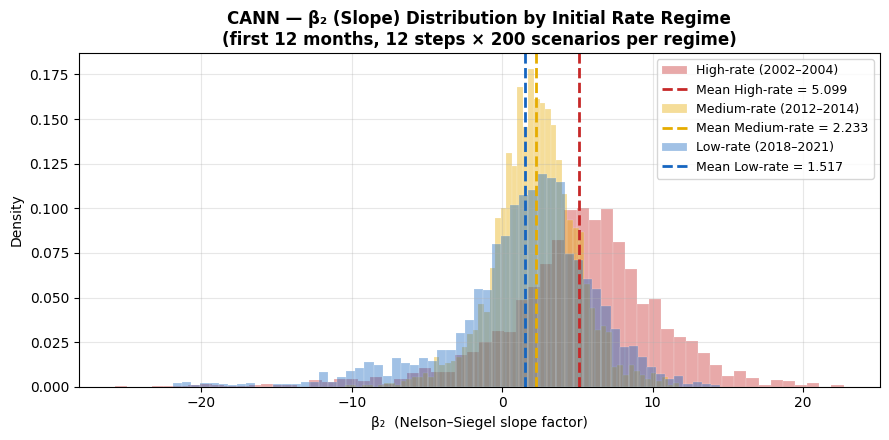

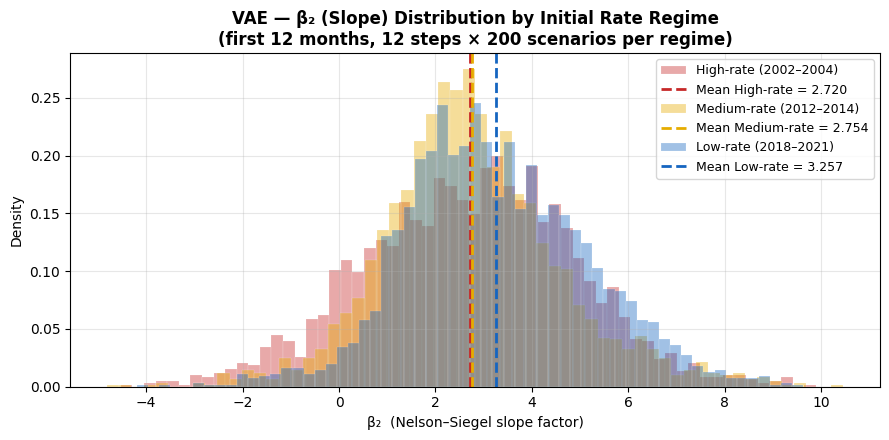

In [64]:
for model_name, regime_b2 in model_beta2.items():
    fig, ax = plt.subplots(figsize=(9, 4.5))

    for rid, b2 in sorted(regime_b2.items()):
        color = REGIME_COLORS[rid]
        label = REGIMES.get(rid, f"Curve {rid}")
        mean  = b2.mean()

        ax.hist(b2, bins=60, density=True, alpha=0.40,
                color=color, edgecolor="white", linewidth=0.3, label=label)
        ax.axvline(mean, color=color, linewidth=2, linestyle="--",
                   label=f"Mean {label.split()[0]} = {mean:.3f}")

    ax.set_title(f"{model_name} — β₂ (Slope) Distribution by Initial Rate Regime\n"
                 f"(first 12 months, {N_MONTHS} steps × 200 scenarios per regime)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("β₂  (Nelson–Siegel slope factor)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Wasserstein Distances Between Regime Distributions

Pairwise Wasserstein-1 distance between the β₂ distributions of each pair of regimes,
per model. A larger distance indicates stronger sensitivity to the initial yield curve.


In [65]:
from itertools import combinations

pairs = list(combinations(sorted(next(iter(model_beta2.values())).keys()), 2))

rows = []
for model_name, regime_b2 in model_beta2.items():
    avail = sorted(regime_b2.keys())
    for (a, b) in combinations(avail, 2):
        dist = wasserstein_distance(regime_b2[a], regime_b2[b])
        rows.append({
            "Model":       model_name,
            "Regime A":    REGIMES.get(a, f"Curve {a}"),
            "Regime B":    REGIMES.get(b, f"Curve {b}"),
            "Wasserstein": round(dist, 4),
        })

wass_df = pd.DataFrame(rows)

print("=" * 80)
print("  Wasserstein Distance — β₂ distributions across regimes")
print("  (higher = model more sensitive to initial yield curve)")
print("=" * 80)
for model_name in model_beta2:
    sub = wass_df[wass_df["Model"] == model_name]
    print(f"\n  {model_name}")
    print(sub.drop(columns="Model").to_string(index=False))


  Wasserstein Distance — β₂ distributions across regimes
  (higher = model more sensitive to initial yield curve)

  Diffusion
               Regime A                Regime B  Wasserstein
  High-rate (2002–2004) Medium-rate (2012–2014)       2.7226
  High-rate (2002–2004)    Low-rate (2018–2021)       3.9436
Medium-rate (2012–2014)    Low-rate (2018–2021)       1.6489

  HJM-PCA
               Regime A                Regime B  Wasserstein
  High-rate (2002–2004) Medium-rate (2012–2014)       2.5420
  High-rate (2002–2004)    Low-rate (2018–2021)       4.3608
Medium-rate (2012–2014)    Low-rate (2018–2021)       1.8187

  CANN
               Regime A                Regime B  Wasserstein
  High-rate (2002–2004) Medium-rate (2012–2014)       3.4844
  High-rate (2002–2004)    Low-rate (2018–2021)       3.5875
Medium-rate (2012–2014)    Low-rate (2018–2021)       1.3227

  VAE
               Regime A                Regime B  Wasserstein
  High-rate (2002–2004) Medium-rate (2012–2014)       

## Volatility Term Structure by Rate Environment

For each model: one plot with three lines (one per regime).
Volatility = std of month-to-month yield changes across the first 12 months, per maturity.
Thin lines = individual scenarios; thick line = mean across all 200 scenarios per regime.


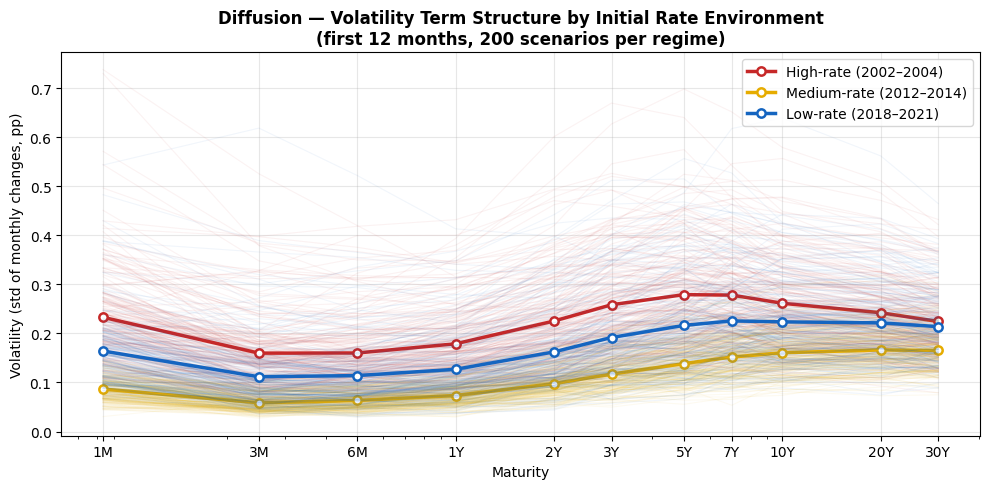

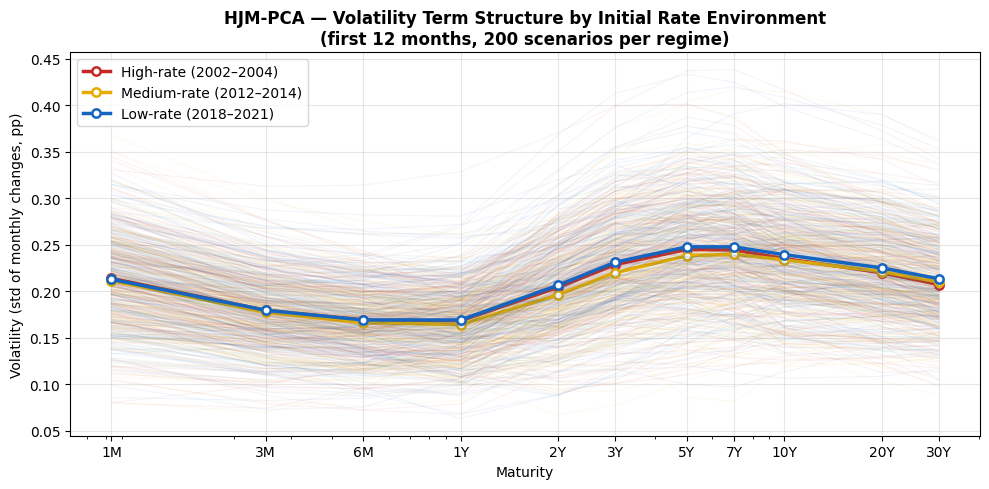

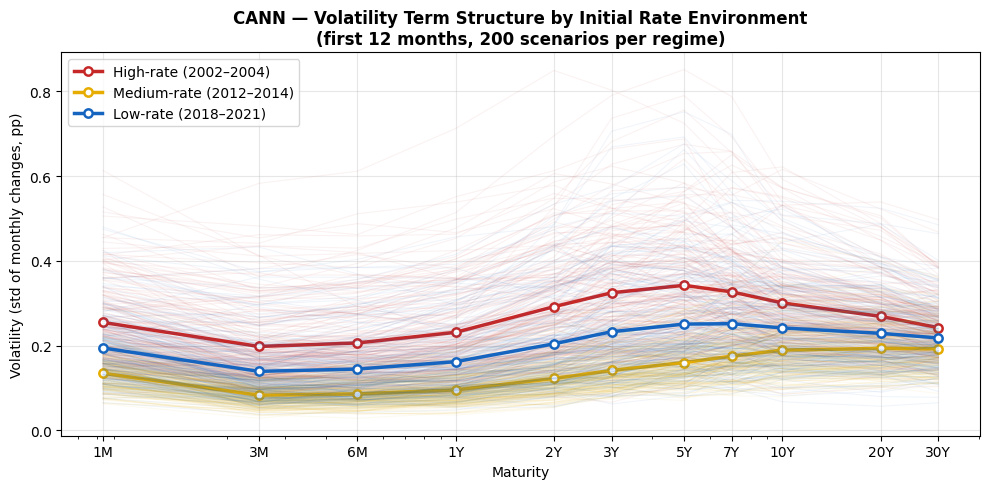

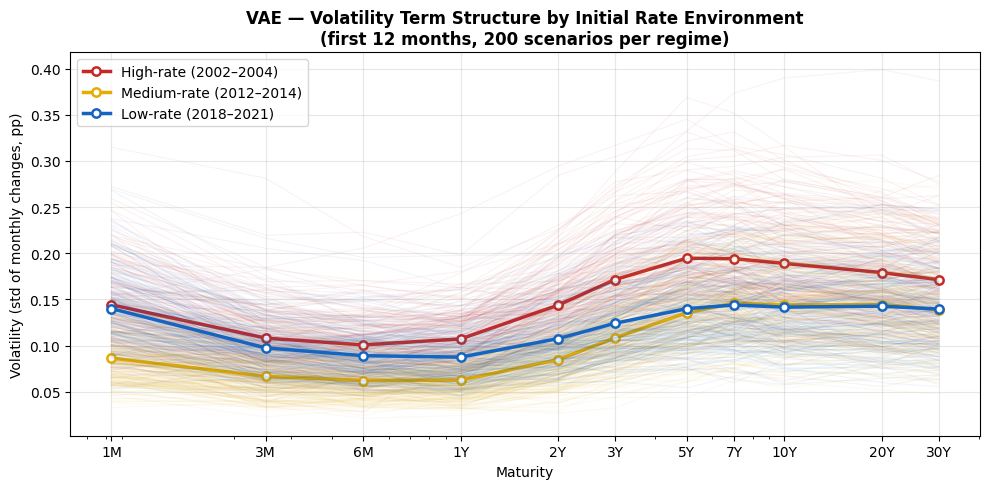

In [66]:
MATURITY_YEARS  = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
MATURITY_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]

def vol_curve_from_windows(windows, n_months=12):
    """
    For each scenario window (T, 11), take first n_months rows,
    compute std of monthly changes per maturity.
    Returns array (N_scenarios, 11).
    """
    curves = []
    for w in windows:
        segment = w[:n_months]          # (12, 11)
        changes = np.diff(segment, axis=0)   # (11, 11)
        curves.append(changes.std(axis=0))   # (11,)  — std per maturity
    return np.array(curves)             # (N, 11)

MODELS_DATA = {
    "Diffusion": load_conditional_data("diffusion_3 scenarios 6-5.csv"),
    "HJM-PCA":   load_conditional_data("hjm_pca_3 scenarios 6-5.csv"),
    "CANN":    load_conditional_data("cann_3 scenarios 10-5.csv"),
    "VAE":     load_conditional_data("VAE_3 scenarios 10-5.csv"),
}

for model_name, regime_dict in MODELS_DATA.items():
    fig, ax = plt.subplots(figsize=(10, 5))

    for rid, windows in sorted(regime_dict.items()):
        color = REGIME_COLORS[rid]
        label = REGIMES.get(rid, f"Curve {rid}")

        vol_curves = vol_curve_from_windows(windows, n_months=N_MONTHS)  # (N, 11)

        # Thin individual scenario lines
        for v in vol_curves:
            ax.plot(MATURITY_YEARS, v, color=color, alpha=0.06, lw=0.8)

        # Thick mean line
        ax.plot(MATURITY_YEARS, vol_curves.mean(axis=0),
                color=color, lw=2.5,
                marker="o", markersize=6,
                markerfacecolor="white", markeredgewidth=1.8,
                label=label)

    ax.set_xscale("log")
    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(MATURITY_LABELS)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Volatility (std of monthly changes, pp)")
    ax.set_title(f"{model_name} — Volatility Term Structure by Initial Rate Environment\n"
                 f"(first {N_MONTHS} months, 200 scenarios per regime)",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [67]:
# ── 1M Volatility: mean per regime + pairwise distances ──────────────────────
from itertools import combinations

MAT_1M_IDX = 0   # index of 1M in the 11-maturity array

print("=" * 65)
print("  Average 1M Volatility by Model and Rate Environment")
print("  (std of monthly yield changes, first 12 months, pp)")
print("=" * 65)

vol_1m = {}   # model → {regime_id → mean 1M vol}

for model_name, regime_dict in MODELS_DATA.items():
    vol_1m[model_name] = {}
    print(f"\n  {model_name}")
    for rid, windows in sorted(regime_dict.items()):
        vc   = vol_curve_from_windows(windows, n_months=N_MONTHS)  # (N, 11)
        mean = vc[:, MAT_1M_IDX].mean()
        vol_1m[model_name][rid] = mean
        label = REGIMES.get(rid, f"Curve {rid}")
        print(f"    {label:28s}: {mean:.4f} pp")

print()
print("=" * 65)
print("  Pairwise Distances — 1M Volatility across Regimes")
print("  (|mean_vol_A − mean_vol_B|)")
print("=" * 65)

for model_name, rid_means in vol_1m.items():
    avail = sorted(rid_means.keys())
    print(f"\n  {model_name}")
    for a, b in combinations(avail, 2):
        dist  = abs(rid_means[a] - rid_means[b])
        la    = REGIMES.get(a, f"Curve {a}").split()[0]
        lb    = REGIMES.get(b, f"Curve {b}").split()[0]
        print(f"    {la:8s} vs {lb:8s}: {dist:.4f} pp")


  Average 1M Volatility by Model and Rate Environment
  (std of monthly yield changes, first 12 months, pp)

  Diffusion
    High-rate (2002–2004)       : 0.2330 pp
    Medium-rate (2012–2014)     : 0.0867 pp
    Low-rate (2018–2021)        : 0.1643 pp

  HJM-PCA
    High-rate (2002–2004)       : 0.2138 pp
    Medium-rate (2012–2014)     : 0.2112 pp
    Low-rate (2018–2021)        : 0.2127 pp

  CANN
    High-rate (2002–2004)       : 0.2548 pp
    Medium-rate (2012–2014)     : 0.1348 pp
    Low-rate (2018–2021)        : 0.1946 pp

  VAE
    High-rate (2002–2004)       : 0.1441 pp
    Medium-rate (2012–2014)     : 0.0864 pp
    Low-rate (2018–2021)        : 0.1400 pp

  Pairwise Distances — 1M Volatility across Regimes
  (|mean_vol_A − mean_vol_B|)

  Diffusion
    High-rate vs Medium-rate: 0.1464 pp
    High-rate vs Low-rate: 0.0688 pp
    Medium-rate vs Low-rate: 0.0776 pp

  HJM-PCA
    High-rate vs Medium-rate: 0.0026 pp
    High-rate vs Low-rate: 0.0011 pp
    Medium-rate vs Low-ra

## Comparison to Historical β₂ Distributions

For each rate regime, the model-generated β₂ distributions (first 12 months) are compared
to the **historical β₂ distribution** from the corresponding period:
- High-rate → 2002–2004
- Medium-rate → 2012–2014
- Low-rate → 2018–2021

A model performs well if its distribution both **differs across regimes** (sensitivity)
and **aligns with the historical pattern** (realism).


In [68]:
# ── Load historical data & compute β₂ per period ─────────────────────────────
HIST_PATH = "../historical data train.csv"
YIELD_COLS_HIST = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
                   "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]

HIST_PERIODS = {
    1: ("2002-01", "2004-12"),   # High-rate
    2: ("2012-01", "2014-12"),   # Medium-rate
    3: ("2018-01", "2021-12"),   # Low-rate
}

df_hist = pd.read_csv(HIST_PATH)
df_hist["DATE"] = pd.to_datetime(df_hist["DATE"])
df_hist = df_hist.sort_values("DATE")
hist_monthly = (df_hist.set_index("DATE")[YIELD_COLS_HIST]
                .resample("ME").last().dropna())

hist_beta2 = {}
for rid, (start, end) in HIST_PERIODS.items():
    sub = hist_monthly.loc[start:end]
    b2s = []
    for _, row in sub.iterrows():
        b, *_ = lstsq(NS_BASIS, row.values.astype(float), rcond=None)
        b2s.append(b[1])
    hist_beta2[rid] = np.array(b2s)
    label = REGIMES.get(rid, f"Curve {rid}")
    print(f"  {label:28s}: {len(b2s):3d} monthly obs  "
          f"(mean β₂ = {np.mean(b2s):.4f})")


  High-rate (2002–2004)       :  36 monthly obs  (mean β₂ = 3.9208)
  Medium-rate (2012–2014)     :  36 monthly obs  (mean β₂ = -0.6845)
  Low-rate (2018–2021)        :  40 monthly obs  (mean β₂ = -1.3172)


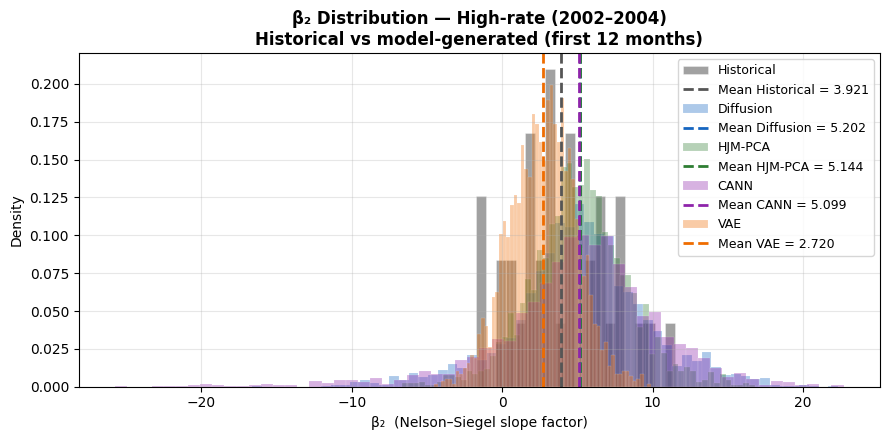

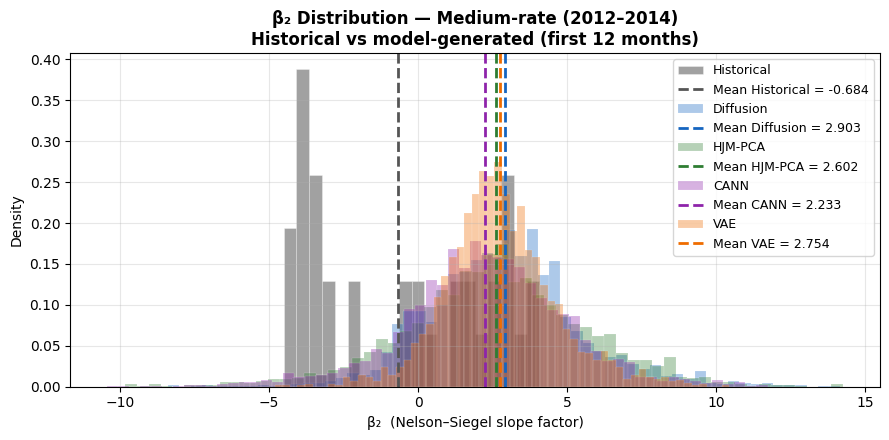

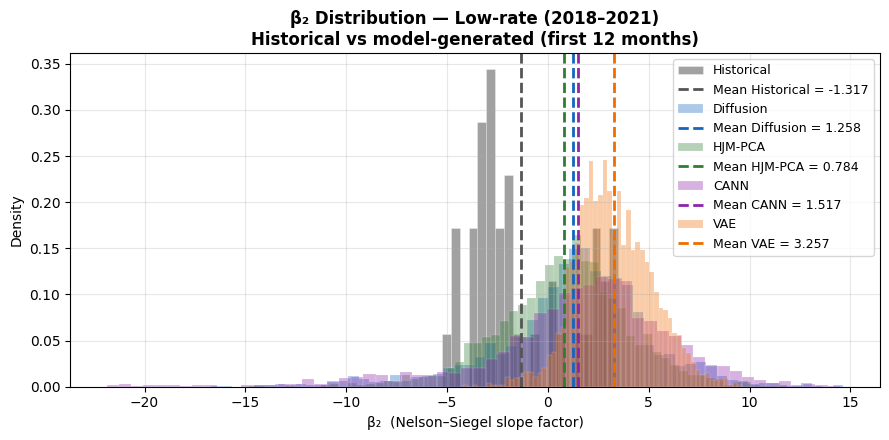

In [69]:
# ── Plot: one figure per regime, historical + all models ─────────────────────
for rid in sorted(hist_beta2.keys()):
    label    = REGIMES.get(rid, f"Curve {rid}")
    hist_b2  = hist_beta2[rid]

    fig, ax = plt.subplots(figsize=(9, 4.5))

    # Historical — grey filled
    ax.hist(hist_b2, bins=20, density=True, alpha=0.55,
            color="#555555", edgecolor="white", linewidth=0.4, label="Historical")
    ax.axvline(hist_b2.mean(), color="#555555", linewidth=2, linestyle="--",
               label=f"Mean Historical = {hist_b2.mean():.3f}")

    # Each model
    for model_name, regime_b2 in model_beta2.items():
        if rid not in regime_b2:
            continue
        b2    = regime_b2[rid]
        color = MODEL_COLORS[model_name]
        ax.hist(b2, bins=60, density=True, alpha=0.35,
                color=color, edgecolor="white", linewidth=0.3, label=model_name)
        ax.axvline(b2.mean(), color=color, linewidth=2, linestyle="--",
                   label=f"Mean {model_name} = {b2.mean():.3f}")

    ax.set_title(f"β₂ Distribution — {label}\nHistorical vs model-generated (first 12 months)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("β₂  (Nelson–Siegel slope factor)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [70]:
# ── Wasserstein distance: each model vs historical, per regime ────────────────
rows = []
for rid in sorted(hist_beta2.keys()):
    label   = REGIMES.get(rid, f"Curve {rid}")
    hist_b2 = hist_beta2[rid]
    for model_name, regime_b2 in model_beta2.items():
        if rid not in regime_b2:
            continue
        dist = wasserstein_distance(hist_b2, regime_b2[rid])
        rows.append({
            "Regime":      label,
            "Model":       model_name,
            "Wasserstein (model vs historical)": round(dist, 4),
        })

wass_hist_df = pd.DataFrame(rows)

print("=" * 70)
print("  Wasserstein Distance — Model β₂ vs Historical β₂")
print("  (lower = model distribution closer to historical pattern)")
print("=" * 70)
for rid in sorted(hist_beta2.keys()):
    label = REGIMES.get(rid, f"Curve {rid}")
    sub   = wass_hist_df[wass_hist_df["Regime"] == label]
    print(f"\n  {label}")
    print(sub.drop(columns="Regime").to_string(index=False))


  Wasserstein Distance — Model β₂ vs Historical β₂
  (lower = model distribution closer to historical pattern)

  High-rate (2002–2004)
    Model  Wasserstein (model vs historical)
Diffusion                             1.7508
  HJM-PCA                             1.2981
     CANN                             2.1702
      VAE                             1.2805

  Medium-rate (2012–2014)
    Model  Wasserstein (model vs historical)
Diffusion                             3.6077
  HJM-PCA                             3.3584
     CANN                             2.9739
      VAE                             3.4391

  Low-rate (2018–2021)
    Model  Wasserstein (model vs historical)
Diffusion                             3.0274
  HJM-PCA                             2.2775
     CANN                             3.7037
      VAE                             4.5741
